# 1. Prepare input

In [18]:
import pandas as pd
import numpy as np
from pathlib import Path

input_file = Path("outputs/model2_conditional_volatility.csv")

tvp_data = pd.read_csv(
    input_file,
    parse_dates=["Date"]
)

tvp_data = (
    tvp_data
    .sort_values("Date")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .set_index("Date")
)

tvp_data.head()

,BTC,SJC,VNINDEX
Date,,,
2023-08-02,2.276917,0.210944,1.209943
2023-08-03,2.391194,0.211427,1.100940
2023-08-04,2.308372,0.228317,1.160359
2023-08-07,2.267835,0.233111,1.120516
2023-08-08,2.197017,0.232300,1.075406


In [19]:
expected_columns = ["BTC", "SJC", "VNINDEX"]

assert list(tvp_data.columns) == expected_columns
assert tvp_data.index.is_monotonic_increasing
assert not tvp_data.isna().any().any()
assert (tvp_data > 0).all().all()

print("Shape:", tvp_data.shape)
print("Date range:", tvp_data.index.min(), "→", tvp_data.index.max())
print(tvp_data.describe())

Shape: (747, 3)
Date range: 2023-08-02 00:00:00 → 2026-07-31 00:00:00
              BTC         SJC     VNINDEX
count  747.000000  747.000000  747.000000
mean     3.138430    1.584696    1.109501
std      0.543944    0.796758    0.413432
min      2.079419    0.210944    0.610955
25%      2.758324    1.090123    0.852673
50%      3.100129    1.431278    1.007766
75%      3.437928    1.921690    1.234266
max      5.646079    5.907931    3.983911


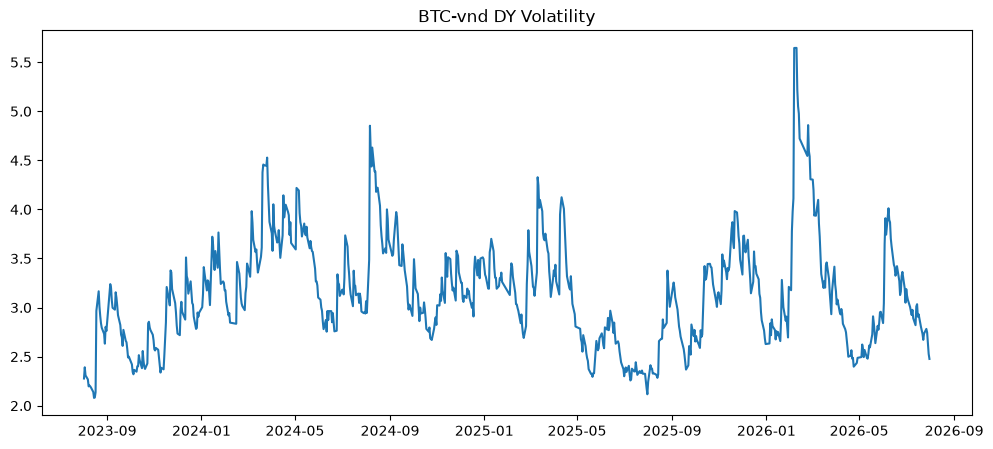

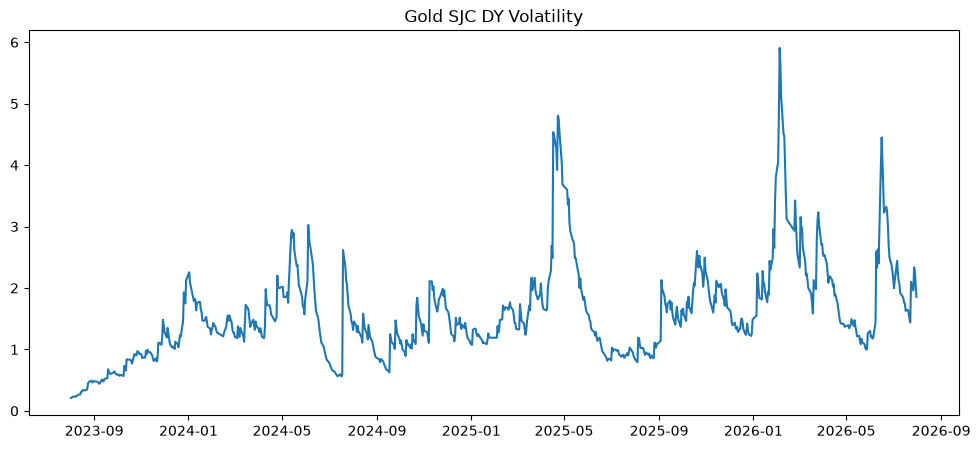

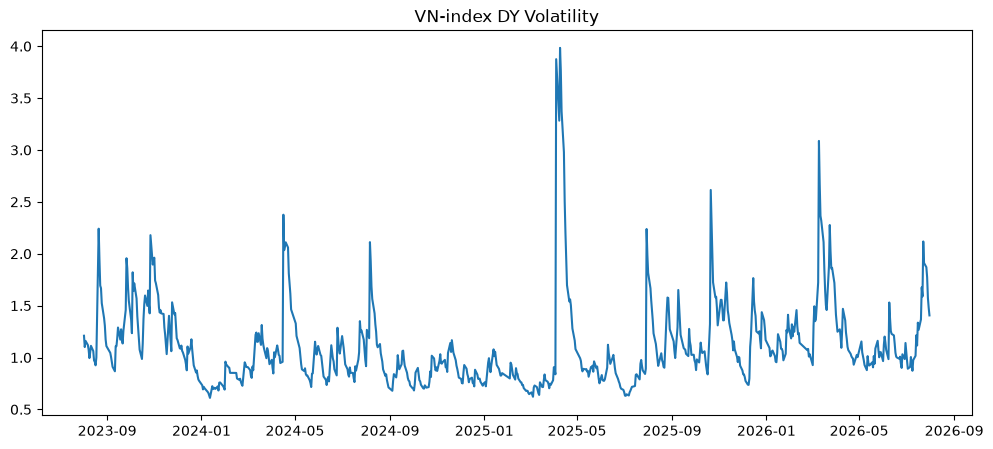

In [20]:
# Vẽ plot dữ liệu các prices

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(tvp_data['BTC'])
plt.title("BTC-vnd DY Volatility")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(tvp_data['SJC'])
plt.title("Gold SJC DY Volatility")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(tvp_data['VNINDEX'])
plt.title("VN-index DY Volatility")
plt.show()

# 2. Stationary

## ADF, PP và KPSS test

Vì volatility không dao động quanh 0, luôn dương, nên lựa chọn test tính dừng có drift ('c')

In [21]:
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron

In [22]:
vol_cols = ["BTC", "SJC", "VNINDEX"]

stationarity_results = []


for asset in vol_cols:

    x = (
        tvp_data[asset]
        .dropna()
        .astype(float)
    )

    # 1. ADF TEST
    # H0: Unit root / Non-stationary
    adf_result = adfuller(
        x,
        regression="c",
        autolag="AIC"
    )

    adf_stat = adf_result[0]
    adf_p = adf_result[1]
    adf_lag = adf_result[2]


    # 2. PHILLIPS-PERRON TEST
    # H0: Unit root / Non-stationary
    pp_result = PhillipsPerron(
        x,
        trend="c"
    )

    pp_stat = pp_result.stat
    pp_p = pp_result.pvalue


    # 3. KPSS TEST
    # H0: Stationary
    kpss_result = kpss(
        x,
        regression="c",
        nlags="auto"
    )

    kpss_stat = kpss_result[0]
    kpss_p = kpss_result[1]
    kpss_lag = kpss_result[2]


    stationarity_results.append({

        "Asset": asset,

        "ADF Statistic": adf_stat,
        "ADF p-value": adf_p,
        "ADF Lag": adf_lag,

        "PP Statistic": pp_stat,
        "PP p-value": pp_p,

        "KPSS Statistic": kpss_stat,
        "KPSS p-value": kpss_p,
        "KPSS Lag": kpss_lag
    })


# ============================================================
# RESULT TABLE
# ============================================================

stationarity_table = pd.DataFrame(
    stationarity_results
).set_index("Asset")


print("=" * 50)
print("STATIONARITY TESTS - CONDITIONAL VOLATILITY")
print("=" * 50)
print(stationarity_table.round(6).to_string())


STATIONARITY TESTS - CONDITIONAL VOLATILITY
         ADF Statistic  ADF p-value  ADF Lag  PP Statistic  PP p-value  KPSS Statistic  KPSS p-value  KPSS Lag
Asset                                                                                                         
BTC          -4.818064     0.000050        3     -4.722934    0.000076        0.177615          0.10        17
SJC          -4.944503     0.000029        5     -4.220941    0.000607        1.194747          0.01        17
VNINDEX      -7.119816     0.000000        2     -6.860004    0.000000        0.294107          0.10        16


/var/folders/86/1060tmrx2ssckzy0244rh3jr0000gn/T/ipykernel_65599/723959834.py:40: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(
/var/folders/86/1060tmrx2ssckzy0244rh3jr0000gn/T/ipykernel_65599/723959834.py:40: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(
/var/folders/86/1060tmrx2ssckzy0244rh3jr0000gn/T/ipykernel_65599/723959834.py:40: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(


### Kết quả test tính dừng

* BTC volatility: dừng ở ADF test, PP test và KPSS test
* SJC volatility: chuỗi dừng ở ADF test và PP test, tuy nhiên KPSS cho kết quả không nhất quán, vì thế cần kiểm tra điểm gãy cấu trúc của dữ liệu
* VN-Index volatility: dừng ở ADF test, PP và KPSS test

## Xem xét structural breaks đối với SJC

In [23]:
import pandas as pd
from statsmodels.tsa.stattools import zivot_andrews

x = (
    tvp_data["SJC"]
    .dropna()
    .astype(float)
)

za_stat, za_pvalue, za_cv, za_baselag, za_break = zivot_andrews(
    x,
    trim=0.15,
    maxlag=None,
    regression="ct",
    autolag="AIC"
)

break_date = x.index[za_break]

print("=" * 50)
print("ZIVOT-ANDREWS TEST - SJC CONDITIONAL VOLATILITY")
print("=" * 50)

print(f"ZA Statistic       : {za_stat:.6f}")
print(f"p-value            : {za_pvalue:.6f}")
print(f"Selected lag       : {za_baselag}")
print(f"Break index        : {za_break}")
print(f"Estimated break date: {break_date}")

print("\nCritical values:")
for level, value in za_cv.items():
    print(f"{level}: {value:.6f}")

ZIVOT-ANDREWS TEST - SJC CONDITIONAL VOLATILITY
ZA Statistic       : -6.113864
p-value            : 0.001885
Selected lag       : 5
Break index        : 207
Estimated break date: 2024-06-04 00:00:00

Critical values:
1%: -5.575560
5%: -5.073320
10%: -4.826680


### Kết quả ZA test của SJC

Chuỗi SJC DY Volatility có đủ cơ sở bác bỏ H0 của ZA test, điểm gãy cấu trúc được estimate vào ngày 04/06/2024. 

* H0: Chuỗi có nghiệm đơn vị và có điểm gãy cấu trúc
* H1: Chuỗi dừng xung quanh một xu hướng gãy có cấu trúc

# 3. Lag p TVP-VAR

Theo 4 tiêu chí thông tin:
1. AIC
2. BIC
3. FPE
4. HQIC

In [24]:
from statsmodels.tsa.api import VAR

# Endogenous variables
var_data = (
    tvp_data[
        ["BTC", "SJC", "VNINDEX"]
    ]
    .dropna()
    .copy()
)

# VAR lag-order selection

var_model = VAR(var_data)

lag_selection = var_model.select_order(
    maxlags=20,
    trend="c"
)

print("=" * 50)
print("PRELIMINARY LAG ORDER SELECTION FOR TVP-VAR")
print("=" * 50)

print(lag_selection.summary())

print("\nSelected lag by criterion:")
print("AIC  :", lag_selection.aic)
print("BIC  :", lag_selection.bic)
print("HQIC :", lag_selection.hqic)
print("FPE  :", lag_selection.fpe)

PRELIMINARY LAG ORDER SELECTION FOR TVP-VAR
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -3.627      -3.608     0.02659      -3.620
1       -9.674     -9.599*   6.287e-05     -9.645*
2       -9.666      -9.533   6.343e-05      -9.614
3      -9.683*      -9.494  6.234e-05*      -9.610
4       -9.682      -9.435   6.243e-05      -9.587
5       -9.676      -9.373   6.280e-05      -9.559
6       -9.666      -9.306   6.340e-05      -9.527
7       -9.665      -9.249   6.346e-05      -9.504
8       -9.668      -9.195   6.325e-05      -9.486
9       -9.677      -9.147   6.270e-05      -9.473
10      -9.664      -9.077   6.354e-05      -9.437
11      -9.647      -9.003   6.463e-05      -9.399
12      -9.632      -8.932   6.559e-05      -9.362
13      -9.645      -8.887   6.479e-05      -9.352
14      -9.629      -8.815   6.583e-05      -9.315
15      -9.611      -8.740   6.699e-05

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Theo BIC = 1 và HQIC = 1, chọn baseline p = 1
TVP-VAR(1)

# 4. TVP-VAR(1)

In [25]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR

# TVP-VAR(1) - KALMAN FILTER WITH FORGETTING FACTORS
# Endogenous variables
var_data = (
    tvp_data[["BTC", "SJC", "VNINDEX"]]
    .dropna()
    .astype(float)
    .copy()
)

Y = var_data.to_numpy()

T, K = Y.shape

# TVP-VAR lag order
p = 1

# Forgetting factors

# Coefficient forgetting factor
lambda_beta = 0.999

# Covariance forgetting factor
kappa_sigma = 0.96

# ============================================================
# 1. INITIAL VALUES FROM STATIC VAR(1)
# ============================================================

static_var = VAR(var_data)

static_fit = static_var.fit(
    maxlags=1,
    trend="c"
)

# Static VAR coefficient matrix
# rows    = constant + lagged variables
# columns = equations
B0 = static_fit.params.to_numpy()

# Number of regressors per equation
# constant + K lagged variables
m = K + 1

# Vectorize coefficient matrix
beta_prev = B0.flatten(order="F")

n_beta = len(beta_prev)

# Initial state covariance
P_prev = np.eye(n_beta) * 0.01

# Initial shock covariance matrix
Sigma_prev = np.asarray(
    static_fit.sigma_u
)

# Initial VAR(1) coefficients
A0 = B0[1:, :].T

# Initial intercept
c0 = B0[0, :]


# ============================================================
# 2. STORAGE
# ============================================================

beta_store = np.zeros(
    (T, n_beta)
)

A_store = np.zeros(
    (T, K, K)
)

constant_store = np.zeros(
    (T, K)
)

Sigma_store = np.zeros(
    (T, K, K)
)

innovation_store = np.full(
    (T, K),
    np.nan
)


# ============================================================
# INITIALIZE t = 0
# ============================================================

beta_store[0] = beta_prev

A_store[0] = A0

constant_store[0] = c0

Sigma_store[0] = Sigma_prev

# 3. TVP-VAR(1) KALMAN FILTER
# ============================================================

I_beta = np.eye(n_beta)

for t in range(1, T):

    # --------------------------------------------------------
    # Observation vector
    #
    # z_t = [1, y_(t-1)]
    # --------------------------------------------------------

    z_t = np.concatenate(
        ([1.0], Y[t - 1])
    )

    # Observation matrix
    #
    # y_t = H_t beta_t + epsilon_t
    #
    H_t = np.kron(
        np.eye(K),
        z_t.reshape(1, -1)
    )


    # ========================================================
    # PREDICTION STEP
    # ========================================================

    # Random walk:
    # beta_t|t-1 = beta_(t-1)|t-1

    beta_pred = beta_prev.copy()

    # Forgetting-factor evolution of state uncertainty
    P_pred = P_prev / lambda_beta


    # ========================================================
    # INNOVATION
    # ========================================================

    y_pred = H_t @ beta_pred

    innovation = Y[t] - y_pred


    # Forecast covariance
    F_t = (
        H_t
        @ P_pred
        @ H_t.T
        + Sigma_prev
    )

    # Numerical protection
    F_t += np.eye(K) * 1e-10


    # ========================================================
    # KALMAN GAIN
    # ========================================================

    K_gain = (
        P_pred
        @ H_t.T
        @ np.linalg.inv(F_t)
    )


    # ========================================================
    # UPDATE COEFFICIENTS
    # ========================================================

    beta_new = (
        beta_pred
        + K_gain @ innovation
    )


    # Joseph-style covariance update
    KH = K_gain @ H_t

    P_new = (
        (I_beta - KH)
        @ P_pred
        @ (I_beta - KH).T
        + K_gain
        @ Sigma_prev
        @ K_gain.T
    )

    # Force symmetry
    P_new = (P_new + P_new.T) / 2


    # UPDATE SHOCK COVARIANCE MATRIX
    # ========================================================

    Sigma_new = (
        kappa_sigma * Sigma_prev
        +
        (1 - kappa_sigma)
        * np.outer(
            innovation,
            innovation
        )
    )

    # Force symmetry
    Sigma_new = (
        Sigma_new
        + Sigma_new.T
    ) / 2

    # Numerical protection
    Sigma_new += np.eye(K) * 1e-10


    # ========================================================
    # RECOVER VAR COEFFICIENT MATRIX
    # ========================================================

    B_t = beta_new.reshape(
        (m, K),
        order="F"
    )

    # Constant
    constant_t = B_t[0, :]

    # VAR(1) coefficient matrix
    #
    # y_t = c_t + A_t y_(t-1) + eps_t
    #
    A_t = B_t[1:, :].T


    # ========================================================
    # STORE RESULTS
    # ========================================================

    beta_store[t] = beta_new

    constant_store[t] = constant_t

    A_store[t] = A_t

    Sigma_store[t] = Sigma_new

    innovation_store[t] = innovation


    # Prepare next iteration
    beta_prev = beta_new
    P_prev = P_new
    Sigma_prev = Sigma_new


# ============================================================
# 4. CREATE TIME INDEX
# ============================================================

tvp_dates = var_data.index


# ============================================================
# 5. BASIC OUTPUT
# ============================================================

print("=" * 60)
print("TVP-VAR(1) ESTIMATION COMPLETED")
print("=" * 60)

print(f"Observations             : {T}")
print(f"Number of variables      : {K}")
print(f"Lag order                : {p}")
print(f"Coefficient forgetting λ : {lambda_beta}")
print(f"Covariance forgetting κ  : {kappa_sigma}")

print("\nVariables:")
print(list(var_data.columns))

print("\nA_t shape:")
print(A_store.shape)

print("\nSigma_t shape:")
print(Sigma_store.shape)

print("\nFinal TVP-VAR coefficient matrix A_T:")
print(
    pd.DataFrame(
        A_store[-1],
        index=var_data.columns,
        columns=var_data.columns
    ).round(6)
)

print("\nFinal shock covariance matrix Sigma_T:")
print(
    pd.DataFrame(
        Sigma_store[-1],
        index=var_data.columns,
        columns=var_data.columns
    ).round(6)
)

TVP-VAR(1) ESTIMATION COMPLETED
Observations             : 747
Number of variables      : 3
Lag order                : 1
Coefficient forgetting λ : 0.999
Covariance forgetting κ  : 0.96

Variables:
['BTC', 'SJC', 'VNINDEX']

A_t shape:
(747, 3, 3)

Sigma_t shape:
(747, 3, 3)

Final TVP-VAR coefficient matrix A_T:
              BTC       SJC   VNINDEX
BTC      0.950943  0.014676 -0.009996
SJC      0.038066  0.950629  0.042509
VNINDEX  0.009671  0.014850  0.891706

Final shock covariance matrix Sigma_T:
              BTC       SJC   VNINDEX
BTC      0.015976 -0.001710 -0.000933
SJC     -0.001710  0.077807  0.002076
VNINDEX -0.000933  0.002076  0.026535


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


# 5. Stability TVP-VAR(1)

TVP-VAR(1) STABILITY CHECK
Observations              : 747
Stable periods            : 733
Unstable periods          : 14
Share stable              : 0.9813

Spectral radius summary:
count    747.000000
mean       0.971370
std        0.013924
min        0.927852
25%        0.957637
50%        0.972755
75%        0.982227
max        1.026851
Name: Spectral Radius, dtype: float64

Maximum spectral radius:
1.0268512230532167

Date of maximum spectral radius:
2024-01-02 00:00:00

Number of unstable dates:
14

First unstable periods:
            Spectral Radius  Stable
Date                               
2023-11-29         1.013382   False
2023-12-26         1.015893   False
2023-12-27         1.010754   False
2023-12-28         1.005072   False
2023-12-29         1.022009   False
2024-01-02         1.026851   False
2024-01-03         1.017709   False
2024-01-04         1.017123   False
2024-01-05         1.011961   False
2024-01-08         1.002773   False


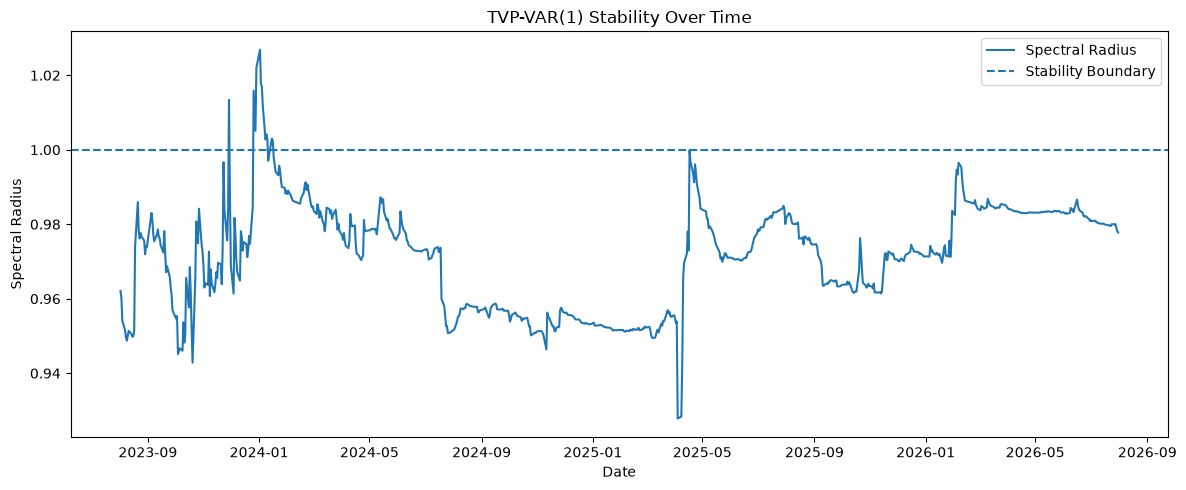

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# TVP-VAR(1) STABILITY CHECK
# Spectral radius of A_t at each time point
# ============================================================

T = A_store.shape[0]

spectral_radius = np.zeros(T)

for t in range(T):

    eigenvalues = np.linalg.eigvals(A_store[t])

    spectral_radius[t] = np.max(
        np.abs(eigenvalues)
    )


# ============================================================
# CREATE RESULT TABLE
# ============================================================

stability_table = pd.DataFrame(
    {
        "Spectral Radius": spectral_radius,
        "Stable": spectral_radius < 1
    },
    index=tvp_dates[:T]
)


# ============================================================
# SUMMARY
# ============================================================

n_stable = stability_table["Stable"].sum()
n_unstable = (~stability_table["Stable"]).sum()

stable_ratio = (
    n_stable / len(stability_table)
)


print("=" * 60)
print("TVP-VAR(1) STABILITY CHECK")
print("=" * 60)

print(f"Observations              : {T}")
print(f"Stable periods            : {n_stable}")
print(f"Unstable periods          : {n_unstable}")
print(f"Share stable              : {stable_ratio:.4f}")

print("\nSpectral radius summary:")
print(
    stability_table[
        "Spectral Radius"
    ].describe().round(6)
)

print("\nMaximum spectral radius:")
print(
    stability_table[
        "Spectral Radius"
    ].max()
)

print("\nDate of maximum spectral radius:")
print(
    stability_table[
        "Spectral Radius"
    ].idxmax()
)


# ============================================================
# UNSTABLE DATES
# ============================================================

unstable_dates = stability_table[
    stability_table["Stable"] == False
]

print("\nNumber of unstable dates:")
print(len(unstable_dates))

if len(unstable_dates) > 0:

    print("\nFirst unstable periods:")
    print(
        unstable_dates.head(10)
    )


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    stability_table.index,
    stability_table["Spectral Radius"],
    label="Spectral Radius"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Stability Boundary"
)

plt.xlabel("Date")
plt.ylabel("Spectral Radius")
plt.title(
    "TVP-VAR(1) Stability Over Time"
)

plt.legend()
plt.tight_layout()
plt.show()

In [27]:
unstable_dates = stability_table[
    stability_table["Spectral Radius"] >= 1
]

print(unstable_dates)

mask = stability_table["Spectral Radius"] >= 1

positions = np.where(mask)[0]

unstable = stability_table.loc[mask].copy()
unstable["Position"] = positions

unstable["Episode"] = (
    unstable["Position"]
    .diff()
    .ne(1)
    .cumsum()
)

episodes = (
    unstable
    .groupby("Episode")
    .agg(
        Start=("Position",
               lambda x: stability_table.index[x.iloc[0]]),
        End=("Position",
             lambda x: stability_table.index[x.iloc[-1]]),
        Duration=("Position", "size"),
        Max_Radius=("Spectral Radius", "max")
    )
)

print(episodes)

            Spectral Radius  Stable
Date                               
2023-11-29         1.013382   False
2023-12-26         1.015893   False
2023-12-27         1.010754   False
2023-12-28         1.005072   False
2023-12-29         1.022009   False
2024-01-02         1.026851   False
2024-01-03         1.017709   False
2024-01-04         1.017123   False
2024-01-05         1.011961   False
2024-01-08         1.002773   False
2024-01-09         1.004173   False
2024-01-10         1.002969   False
2024-01-15         1.002987   False
2024-01-16         1.002390   False
             Start        End  Duration  Max_Radius
Episode                                            
1       2023-11-29 2023-11-29         1    1.013382
2       2023-12-26 2024-01-10        11    1.026851
3       2024-01-15 2024-01-16         2    1.002987


In [28]:
import numpy as np
import pandas as pd

# ============================================================
# TVP-GFEVD - H = 10
# ============================================================

H = 10

T, K, _ = A_store.shape

# Storage:
# theta_store[t, i, j]
# = contribution of shock j
#   to forecast error variance of variable i
theta_store = np.zeros((T, K, K))


# ============================================================
# LOOP OVER TIME
# ============================================================

for t in range(T):

    A_t = A_store[t]
    Sigma_t = Sigma_store[t]

    # --------------------------------------------------------
    # 1. COMPUTE MA COEFFICIENTS PHI_h,t
    # --------------------------------------------------------

    # Phi_0 = I
    phi_list = [np.eye(K)]

    for h in range(1, H):
        phi_h = np.linalg.matrix_power(A_t, h)
        phi_list.append(phi_h)


    # --------------------------------------------------------
    # 2. GENERALIZED FEVD
    # --------------------------------------------------------

    theta_t = np.zeros((K, K))

    for i in range(K):

        # Denominator:
        # sum_h (e_i' Phi_h Sigma Phi_h' e_i)

        denominator = 0.0

        for h in range(H):

            Phi_h = phi_list[h]

            temp = (
                Phi_h
                @ Sigma_t
                @ Phi_h.T
            )

            denominator += temp[i, i]


        # Contributions from shock j
        for j in range(K):

            sigma_jj = Sigma_t[j, j]

            numerator = 0.0

            for h in range(H):

                Phi_h = phi_list[h]

                # e_i' Phi_h Sigma e_j
                contribution = (
                    Phi_h
                    @ Sigma_t
                )[i, j]

                numerator += (
                    contribution ** 2
                )

            theta_t[i, j] = (
                numerator
                / sigma_jj
                / denominator
            )


    # --------------------------------------------------------
    # 3. ROW NORMALIZATION
    # --------------------------------------------------------

    row_sums = theta_t.sum(
        axis=1,
        keepdims=True
    )

    theta_t_normalized = (
        theta_t / row_sums
    )

    theta_store[t] = theta_t_normalized


# ============================================================
# BASIC CHECK
# ============================================================

print("=" * 60)
print("TVP-GFEVD COMPLETED")
print("=" * 60)

print(f"Horizon H      : {H}")
print(f"Observations   : {T}")
print(f"Variables      : {K}")

print("\nTheta shape:")
print(theta_store.shape)


# ============================================================
# CHECK FINAL PERIOD
# ============================================================

theta_final = pd.DataFrame(
    theta_store[-1] * 100,
    index=var_data.columns,
    columns=var_data.columns
)

print("\nFinal-period normalized GFEVD (%):")
print(
    theta_final.round(4)
)

print("\nRow sums (%):")
print(
    theta_final.sum(axis=1).round(6)
)

TVP-GFEVD COMPLETED
Horizon H      : 10
Observations   : 747
Variables      : 3

Theta shape:
(747, 3, 3)

Final-period normalized GFEVD (%):
             BTC      SJC  VNINDEX
BTC      98.0591   1.3378   0.6031
SJC       0.2640  97.9587   1.7773
VNINDEX   0.1121   2.6404  97.2476

Row sums (%):
BTC        100.0
SJC        100.0
VNINDEX    100.0
dtype: float64


## Đọc kết quả của TVP-VAR(1)

| Receiver ↓ / Shock → | BTC | SJC | VNINDEX |
|---|---:|---:|---:|
| BTC | 98.0591 | 1.3378 | 0.6031 |
| SJC | 0.2640 | 97.9587 | 1.7773 |
| VNINDEX | 0.1121 | 2.6404 | 97.2476 |

In [29]:
print("Any NaN:",np.isnan(theta_store).any())
print("Any Inf:",np.isinf(theta_store).any())
print("Minimum:",theta_store.min())
print("Maximum:",theta_store.max())
print("Maximum row-sum error:",np.max(np.abs(theta_store.sum(axis=2) - 1)))

Any NaN: False
Any Inf: False
Minimum: 3.392102022390738e-06
Maximum: 0.9997714885270569
Maximum row-sum error: 3.3306690738754696e-16


# 6. Connectedness measure theo thời gian

In [30]:
import numpy as np
import pandas as pd

# ============================================================
# DYNAMIC CONNECTEDNESS MEASURES
# FROM / TO / NET / TCI
# ============================================================

T, K, _ = theta_store.shape

variables = list(var_data.columns)

# Storage
TCI = np.zeros(T)

FROM = np.zeros((T, K))
TO = np.zeros((T, K))
NET = np.zeros((T, K))


# ============================================================
# CALCULATE CONNECTEDNESS AT EACH TIME t
# ============================================================

for t in range(T):

    theta_t = theta_store[t]

    # --------------------------------------------------------
    # FROM connectedness
    #
    # For variable i:
    # sum of off-diagonal elements in ROW i
    # --------------------------------------------------------

    FROM[t] = (
        theta_t.sum(axis=1)
        - np.diag(theta_t)
    )


    # --------------------------------------------------------
    # TO connectedness
    #
    # For variable j:
    # sum of off-diagonal elements in COLUMN j
    # --------------------------------------------------------

    TO[t] = (
        theta_t.sum(axis=0)
        - np.diag(theta_t)
    )


    # --------------------------------------------------------
    # NET connectedness
    #
    # Positive = net transmitter
    # Negative = net receiver
    # --------------------------------------------------------

    NET[t] = TO[t] - FROM[t]


    # --------------------------------------------------------
    # TOTAL CONNECTEDNESS INDEX
    #
    # Since theta rows sum to 1:
    #
    # TCI = sum of all off-diagonal shares / K
    # --------------------------------------------------------

    TCI[t] = (
        np.sum(theta_t)
        - np.trace(theta_t)
    ) / K


# ============================================================
# CONVERT TO PERCENTAGE POINTS
# ============================================================

TCI_pct = TCI * 100
FROM_pct = FROM * 100
TO_pct = TO * 100
NET_pct = NET * 100


# ============================================================
# CREATE DATAFRAMES
# ============================================================

tci_df = pd.DataFrame(
    {
        "TCI": TCI_pct
    },
    index=tvp_dates
)

from_df = pd.DataFrame(
    FROM_pct,
    index=tvp_dates,
    columns=variables
)

to_df = pd.DataFrame(
    TO_pct,
    index=tvp_dates,
    columns=variables
)

net_df = pd.DataFrame(
    NET_pct,
    index=tvp_dates,
    columns=variables
)


# ============================================================
# FINAL-PERIOD CONNECTEDNESS TABLE
# ============================================================

final_connectedness = pd.DataFrame(
    {
        "FROM": FROM_pct[-1],
        "TO": TO_pct[-1],
        "NET": NET_pct[-1]
    },
    index=variables
)


# ============================================================
# OUTPUT
# ============================================================

print("=" * 60)
print("TVP-VAR DYNAMIC CONNECTEDNESS - H=10")
print("=" * 60)

print("\nFinal-period connectedness (%):")
print(
    final_connectedness.round(4)
)

print(
    "\nFinal-period TCI:",
    round(TCI_pct[-1], 4),
    "%"
)

print("\nMean NET connectedness (%):")
print(
    net_df.mean().round(4)
)

print("\nCheck sum of NET at final period:")
print(
    round(
        final_connectedness["NET"].sum(),
        10
    )
)

TVP-VAR DYNAMIC CONNECTEDNESS - H=10

Final-period connectedness (%):
           FROM      TO     NET
BTC      1.9409  0.3761 -1.5648
SJC      2.0413  3.9781  1.9368
VNINDEX  2.7524  2.3804 -0.3720

Final-period TCI: 2.2449 %

Mean NET connectedness (%):
BTC        2.8759
SJC        2.2210
VNINDEX   -5.0969
dtype: float64

Check sum of NET at final period:
0.0


| Asset | FROM | TO | NET | Role cuối sample |
|---|---:|---:|---:|---|
| BTC | 1.9409 | 0.3761 | **−1.5648** | Receiver |
| SJC | 2.0413 | 3.9782 | **+1.9369** | Transmitter |
| VNINDEX | 2.7525 | 2.3804 | **−0.3721** | Receiver |

Kết quả cho thấy tại thời điểm cuối mẫu, mức connectedness tổng thể giữa BTC, SJC và VN-Index tương đối thấp, với TCI = 2.2449%. Xét theo hướng truyền dẫn, SJC là net transmitter với NET = +1.9368%, trong khi BTC (-1.5648%) và VN-Index (-0.3720%) là net receivers; tức là tại cuối kỳ, SJC truyền spillover sang các biến khác nhiều hơn lượng spillover mà nó nhận. Tuy nhiên, xét trung bình toàn bộ giai đoạn, BTC và SJC đều có NET dương (2.8759% và 2.2210%), còn VN-Index có NET âm (-5.0969%), cho thấy vai trò truyền-nhận spillover thay đổi theo thời gian và không nên chỉ dựa vào trạng thái cuối kỳ để kết luận về vai trò của từng biến. Tổng NET bằng 0 xác nhận tính nhất quán của phép tính connectedness.

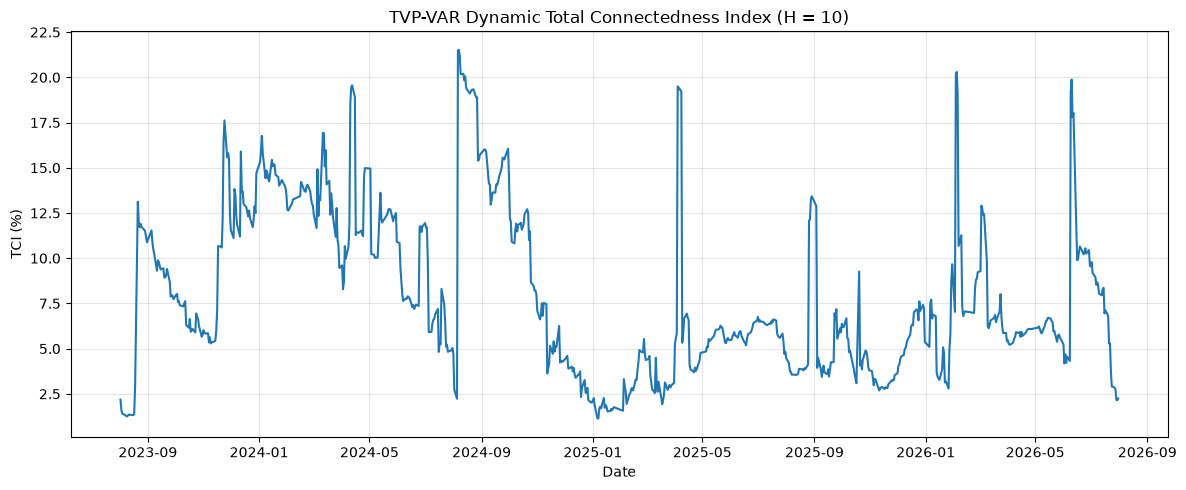

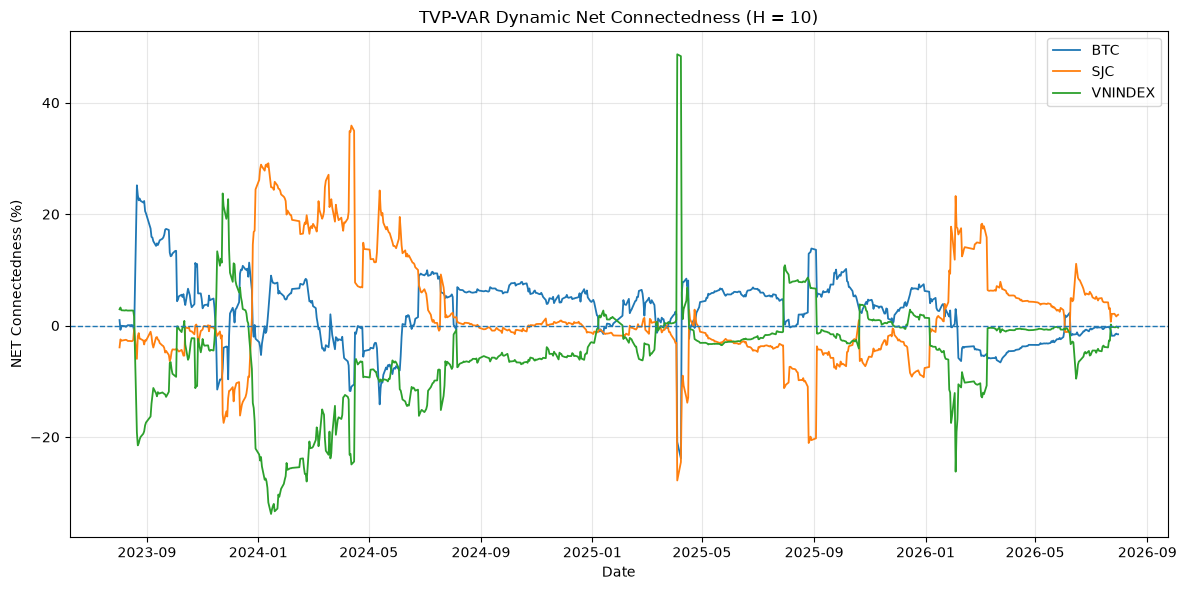

In [31]:
import matplotlib.pyplot as plt

# ============================================================
# 1. DYNAMIC TOTAL CONNECTEDNESS INDEX (TCI_t)
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    tci_df.index,
    tci_df["TCI"],
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("TCI (%)")
plt.title(
    "TVP-VAR Dynamic Total Connectedness Index "
    "(H = 10)"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 2. DYNAMIC NET CONNECTEDNESS
# ============================================================

plt.figure(figsize=(12, 6))

for asset in net_df.columns:

    plt.plot(
        net_df.index,
        net_df[asset],
        linewidth=1.3,
        label=asset
    )

# NET = 0 boundary:
# > 0 : Net transmitter
# < 0 : Net receiver
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("NET Connectedness (%)")

plt.title(
    "TVP-VAR Dynamic Net Connectedness "
    "(H = 10)"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

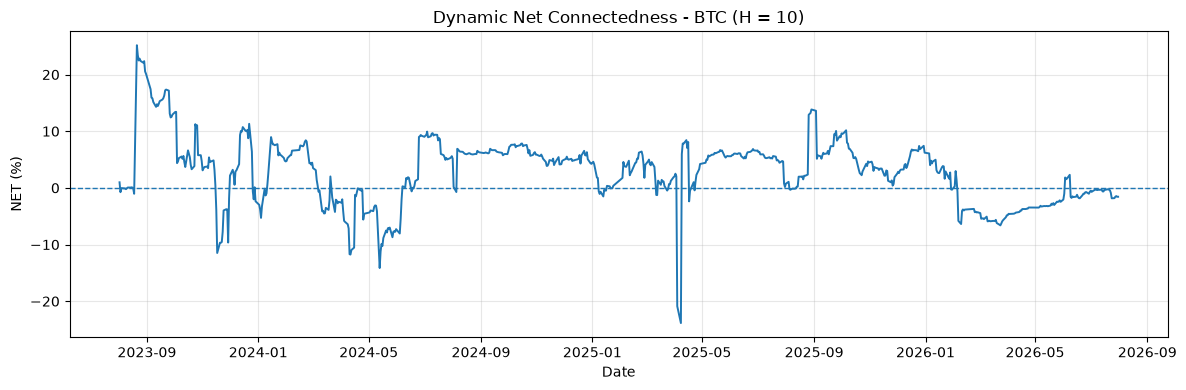

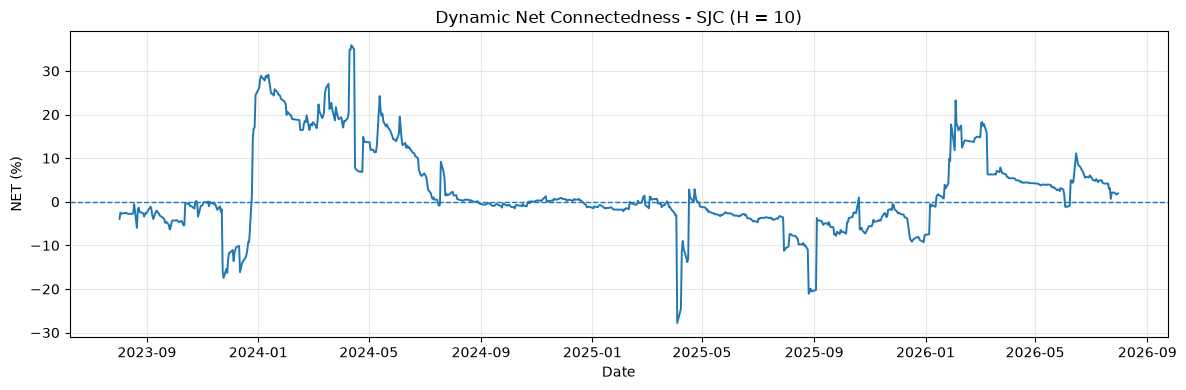

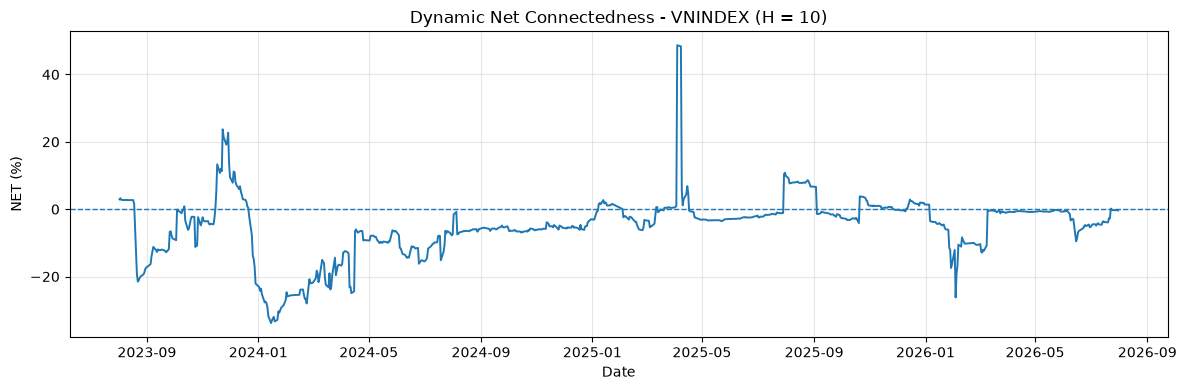

In [32]:
for asset in net_df.columns:

    plt.figure(figsize=(12, 4))

    plt.plot(
        net_df.index,
        net_df[asset],
        linewidth=1.4
    )

    plt.axhline(
        y=0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Date")
    plt.ylabel("NET (%)")

    plt.title(
        f"Dynamic Net Connectedness - {asset} "
        "(H = 10)"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

In [33]:
print("=" * 60)
print("AVERAGE TVP-VAR CONNECTEDNESS - H=10")
print("=" * 60)

print("\nMean TCI:")
print(tci_df["TCI"].mean())

print("\nMean FROM:")
print(from_df.mean().round(4))

print("\nMean TO:")
print(to_df.mean().round(4))

print("\nMean NET:")
print(net_df.mean().round(4))

AVERAGE TVP-VAR CONNECTEDNESS - H=10

Mean TCI:
7.92412042378382

Mean FROM:
BTC         6.4499
SJC         5.6875
VNINDEX    11.6349
dtype: float64

Mean TO:
BTC        9.3258
SJC        7.9085
VNINDEX    6.5380
dtype: float64

Mean NET:
BTC        2.8759
SJC        2.2210
VNINDEX   -5.0969
dtype: float64


# 7. Robustness check

Phương pháp kiểm định độ vững của mô hình là phân tích độ nhạy tham số (parameter sensitivity analysis). Cơ chế: giữ nguyên mô hình, chỉ thay đổi một siêu tham số kỹ thuật tại một thời điểm, sau đó so sánh kết luận có thay đổi hay không. Nếu kết quả về dấu của NET, transmitter/receiver vẫn giữ nguyên qua các lựa chọn tham số khác nhau, thì kết luận được xem là vững.

## TVP-VAR sensitivity implementation

The following cells import the source notebook's six-specification robustness analysis. They use the `var_data` prepared in Parts 1–6 of this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR

ROOT = Path.cwd()
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

## Model and analysis functions

All project logic is defined in this cell so the notebook has no dependency on `src/`.

In [2]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR


@dataclass(frozen=True)
class TVPVARResult:
    dates: pd.Index
    variables: tuple[str, ...]
    lambda_beta: float
    kappa_sigma: float
    initial_covariance: float
    coefficients: np.ndarray
    constants: np.ndarray
    shock_covariances: np.ndarray
    innovations: np.ndarray


def estimate_tvp_var(
    data: pd.DataFrame,
    *,
    lambda_beta: float = 0.999,
    kappa_sigma: float = 0.96,
    initial_covariance: float = 0.01,
) -> TVPVARResult:
    """Estimate the project's TVP-VAR(1) forgetting-factor specification."""
    if not 0 < lambda_beta <= 1:
        raise ValueError("lambda_beta must be in (0, 1]")
    if not 0 < kappa_sigma < 1:
        raise ValueError("kappa_sigma must be in (0, 1)")
    if initial_covariance <= 0:
        raise ValueError("initial_covariance must be positive")
    if data.shape[1] < 2 or len(data) < 3:
        raise ValueError("data must contain at least two variables and three rows")
    if data.isna().any().any() or not np.isfinite(data.to_numpy()).all():
        raise ValueError("data contains missing or non-finite values")

    clean = data.astype(float).copy()
    y = clean.to_numpy()
    n_obs, n_vars = y.shape

    static_fit = VAR(clean).fit(maxlags=1, trend="c")
    initial_parameters = static_fit.params.to_numpy()
    regressors_per_equation = n_vars + 1

    beta_previous = initial_parameters.flatten(order="F")
    n_beta = len(beta_previous)
    state_covariance_previous = np.eye(n_beta) * initial_covariance
    sigma_previous = np.asarray(static_fit.sigma_u)

    beta_store = np.zeros((n_obs, n_beta))
    coefficient_store = np.zeros((n_obs, n_vars, n_vars))
    constant_store = np.zeros((n_obs, n_vars))
    sigma_store = np.zeros((n_obs, n_vars, n_vars))
    innovation_store = np.full((n_obs, n_vars), np.nan)

    beta_store[0] = beta_previous
    coefficient_store[0] = initial_parameters[1:, :].T
    constant_store[0] = initial_parameters[0, :]
    sigma_store[0] = sigma_previous

    identity_beta = np.eye(n_beta)

    for t in range(1, n_obs):
        observation_vector = np.concatenate(([1.0], y[t - 1]))
        observation_matrix = np.kron(
            np.eye(n_vars), observation_vector.reshape(1, -1)
        )

        beta_prediction = beta_previous.copy()
        state_covariance_prediction = (
            state_covariance_previous / lambda_beta
        )
        innovation = y[t] - observation_matrix @ beta_prediction
        forecast_covariance = (
            observation_matrix
            @ state_covariance_prediction
            @ observation_matrix.T
            + sigma_previous
            + np.eye(n_vars) * 1e-10
        )
        kalman_gain = (
            state_covariance_prediction
            @ observation_matrix.T
            @ np.linalg.inv(forecast_covariance)
        )
        beta_new = beta_prediction + kalman_gain @ innovation

        gain_observation = kalman_gain @ observation_matrix
        state_covariance_new = (
            (identity_beta - gain_observation)
            @ state_covariance_prediction
            @ (identity_beta - gain_observation).T
            + kalman_gain @ sigma_previous @ kalman_gain.T
        )
        state_covariance_new = (
            state_covariance_new + state_covariance_new.T
        ) / 2

        sigma_new = (
            kappa_sigma * sigma_previous
            + (1 - kappa_sigma) * np.outer(innovation, innovation)
        )
        sigma_new = (sigma_new + sigma_new.T) / 2
        sigma_new += np.eye(n_vars) * 1e-10

        parameter_matrix = beta_new.reshape(
            (regressors_per_equation, n_vars), order="F"
        )
        beta_store[t] = beta_new
        constant_store[t] = parameter_matrix[0, :]
        coefficient_store[t] = parameter_matrix[1:, :].T
        sigma_store[t] = sigma_new
        innovation_store[t] = innovation

        beta_previous = beta_new
        state_covariance_previous = state_covariance_new
        sigma_previous = sigma_new

    return TVPVARResult(
        dates=clean.index,
        variables=tuple(clean.columns),
        lambda_beta=lambda_beta,
        kappa_sigma=kappa_sigma,
        initial_covariance=initial_covariance,
        coefficients=coefficient_store,
        constants=constant_store,
        shock_covariances=sigma_store,
        innovations=innovation_store,
    )

# %%

import numpy as np



def generalized_fevd(model: TVPVARResult, horizon: int = 10) -> np.ndarray:
    """Compute row-normalized generalized FEVD at each time point."""
    if horizon < 1:
        raise ValueError("horizon must be at least 1")

    n_obs, n_vars, _ = model.coefficients.shape
    theta_store = np.zeros((n_obs, n_vars, n_vars))

    for t in range(n_obs):
        coefficient = model.coefficients[t]
        sigma = model.shock_covariances[t]
        moving_average = [
            np.linalg.matrix_power(coefficient, h) for h in range(horizon)
        ]

        theta = np.zeros((n_vars, n_vars))
        for receiver in range(n_vars):
            denominator = sum(
                (phi @ sigma @ phi.T)[receiver, receiver]
                for phi in moving_average
            )
            for shock in range(n_vars):
                numerator = sum(
                    ((phi @ sigma)[receiver, shock]) ** 2
                    for phi in moving_average
                )
                theta[receiver, shock] = (
                    numerator / sigma[shock, shock] / denominator
                )

        row_sums = theta.sum(axis=1, keepdims=True)
        if np.any(row_sums <= 0) or not np.isfinite(row_sums).all():
            raise FloatingPointError(f"Invalid GFEVD row sum at observation {t}")
        theta_store[t] = theta / row_sums

    return theta_store

# %%

from dataclasses import dataclass

import numpy as np
import pandas as pd


@dataclass(frozen=True)
class ConnectednessResult:
    tci: pd.Series
    from_others: pd.DataFrame
    to_others: pd.DataFrame
    net: pd.DataFrame
    theta: np.ndarray

    @property
    def final_table(self) -> pd.DataFrame:
        return pd.DataFrame(
            {
                "FROM": self.from_others.iloc[-1],
                "TO": self.to_others.iloc[-1],
                "NET": self.net.iloc[-1],
            }
        )


def calculate_connectedness(
    theta: np.ndarray,
    *,
    dates: pd.Index,
    variables: tuple[str, ...],
) -> ConnectednessResult:
    if theta.ndim != 3 or theta.shape[1] != theta.shape[2]:
        raise ValueError("theta must have shape (time, variables, variables)")
    if theta.shape[0] != len(dates) or theta.shape[1] != len(variables):
        raise ValueError("theta dimensions do not match dates and variables")
    if not np.isfinite(theta).all():
        raise ValueError("theta contains non-finite values")
    if not np.allclose(theta.sum(axis=2), 1, atol=1e-10):
        raise ValueError("theta rows must sum to one")

    diagonal = np.diagonal(theta, axis1=1, axis2=2)
    from_others = (theta.sum(axis=2) - diagonal) * 100
    to_others = (theta.sum(axis=1) - diagonal) * 100
    net = to_others - from_others
    tci = from_others.sum(axis=1) / theta.shape[1]

    return ConnectednessResult(
        tci=pd.Series(tci, index=dates, name="TCI"),
        from_others=pd.DataFrame(from_others, index=dates, columns=variables),
        to_others=pd.DataFrame(to_others, index=dates, columns=variables),
        net=pd.DataFrame(net, index=dates, columns=variables),
        theta=theta,
    )

# %%

import numpy as np
import pandas as pd



def stability_table(model: TVPVARResult) -> pd.DataFrame:
    radius = np.array(
        [np.max(np.abs(np.linalg.eigvals(matrix))) for matrix in model.coefficients]
    )
    return pd.DataFrame(
        {"spectral_radius": radius, "stable": radius < 1},
        index=model.dates,
    )


def unstable_episodes(table: pd.DataFrame) -> pd.DataFrame:
    unstable = table.loc[~table["stable"]].copy()
    if unstable.empty:
        return pd.DataFrame(columns=["start", "end", "duration", "max_radius"])

    positions = np.flatnonzero(~table["stable"].to_numpy())
    unstable["position"] = positions
    unstable["episode"] = unstable["position"].diff().ne(1).cumsum()

    records = []
    for _, group in unstable.groupby("episode"):
        records.append(
            {
                "start": group.index[0],
                "end": group.index[-1],
                "duration": len(group),
                "max_radius": group["spectral_radius"].max(),
            }
        )
    return pd.DataFrame(records)


def instability_context(
    table: pd.DataFrame,
    tci: pd.Series,
    net: pd.DataFrame,
) -> pd.DataFrame:
    """Combine unstable dates with connectedness measures for interpretation."""
    if not table.index.equals(tci.index) or not table.index.equals(net.index):
        raise ValueError("stability and connectedness indices must match")
    context = table.loc[~table["stable"]].copy()
    context["TCI"] = tci.loc[context.index]
    for variable in net.columns:
        context[f"NET_{variable}"] = net.loc[context.index, variable]
    return context

# %%

from dataclasses import dataclass

import pandas as pd



@dataclass(frozen=True)
class SpecificationResult:
    name: str
    horizon: int
    model: TVPVARResult
    stability: pd.DataFrame
    episodes: pd.DataFrame
    connectedness: ConnectednessResult

    def summary(self) -> pd.Series:
        result = {
            "lambda_beta": self.model.lambda_beta,
            "kappa_sigma": self.model.kappa_sigma,
            "horizon": self.horizon,
            "stable_share": self.stability["stable"].mean(),
            "unstable_periods": int((~self.stability["stable"]).sum()),
            "max_spectral_radius": self.stability["spectral_radius"].max(),
            "mean_tci": self.connectedness.tci.mean(),
            "final_tci": self.connectedness.tci.iloc[-1],
        }
        result.update(
            {
                f"mean_net_{variable}": value
                for variable, value in self.connectedness.net.mean().items()
            }
        )
        result.update(
            {
                f"final_net_{variable}": value
                for variable, value in self.connectedness.net.iloc[-1].items()
            }
        )
        return pd.Series(result, name=self.name)


def run_specification(
    data: pd.DataFrame,
    *,
    name: str,
    lambda_beta: float,
    kappa_sigma: float = 0.96,
    initial_covariance: float = 0.01,
    horizon: int = 10,
) -> SpecificationResult:
    model = estimate_tvp_var(
        data,
        lambda_beta=lambda_beta,
        kappa_sigma=kappa_sigma,
        initial_covariance=initial_covariance,
    )
    stability = stability_table(model)
    theta = generalized_fevd(model, horizon=horizon)
    connectedness = calculate_connectedness(
        theta, dates=model.dates, variables=model.variables
    )
    return SpecificationResult(
        name=name,
        horizon=horizon,
        model=model,
        stability=stability,
        episodes=unstable_episodes(stability),
        connectedness=connectedness,
    )


def compare_specifications(
    specifications: list[SpecificationResult],
) -> pd.DataFrame:
    if not specifications:
        raise ValueError("at least one specification is required")
    return pd.DataFrame([result.summary() for result in specifications])

# %%

from pathlib import Path

import numpy as np
import pandas as pd



VARIABLES = ("BTC", "SJC", "VNINDEX")


def load_volatility_data(path: str | Path) -> pd.DataFrame:
    data = pd.read_csv(path, parse_dates=["Date"])
    data = (
        data.sort_values("Date")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .set_index("Date")
    )
    if tuple(data.columns) != VARIABLES:
        raise ValueError(f"expected columns {VARIABLES}, got {tuple(data.columns)}")
    if not data.index.is_monotonic_increasing:
        raise ValueError("dates must be monotonically increasing")
    return data.astype(float)


def save_results(result: SpecificationResult, directory: str | Path) -> None:
    output = Path(directory)
    output.mkdir(parents=True, exist_ok=True)
    result.connectedness.tci.to_csv(output / "tci.csv", header=True)
    result.connectedness.from_others.to_csv(output / "from.csv")
    result.connectedness.to_others.to_csv(output / "to.csv")
    result.connectedness.net.to_csv(output / "net.csv")
    result.stability.to_csv(output / "stability.csv")
    result.episodes.to_csv(output / "unstable_episodes.csv", index=False)
    instability_context(
        result.stability,
        result.connectedness.tci,
        result.connectedness.net,
    ).to_csv(output / "unstable_observations.csv")
    result.summary().to_frame("value").to_csv(output / "summary.csv")


def save_comparison(
    results: list[SpecificationResult], path: str | Path
) -> None:
    output = Path(path)
    output.parent.mkdir(parents=True, exist_ok=True)
    compare_specifications(results).to_csv(output)

## Load data and run the six specifications

In [3]:
data = var_data.copy()
display(data.head())

specifications = [
    {'name': 'baseline_0999', 'lambda_beta': 0.999, 'kappa_sigma': 0.96, 'horizon': 10},
    {'name': 'robustness_0997', 'lambda_beta': 0.997, 'kappa_sigma': 0.96, 'horizon': 10},
    {'name': 'kappa_094', 'lambda_beta': 0.999, 'kappa_sigma': 0.94, 'horizon': 10},
    {'name': 'kappa_098', 'lambda_beta': 0.999, 'kappa_sigma': 0.98, 'horizon': 10},
    {'name': 'horizon_05', 'lambda_beta': 0.999, 'kappa_sigma': 0.96, 'horizon': 5},
    {'name': 'horizon_20', 'lambda_beta': 0.999, 'kappa_sigma': 0.96, 'horizon': 20},
]

results = {
    specification['name']: run_specification(data, initial_covariance=0.01, **specification)
    for specification in specifications
}
comparison = compare_specifications(list(results.values()))
comparison

,BTC,SJC,VNINDEX
Date,,,
2023-08-02,2.2769,0.2109,1.2099
2023-08-03,2.3912,0.2114,1.1009
2023-08-04,2.3084,0.2283,1.1604
2023-08-07,2.2678,0.2331,1.1205
2023-08-08,2.1970,0.2323,1.0754


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,lambda_beta,kappa_sigma,horizon,stable_share,unstable_periods,max_spectral_radius,mean_tci,final_tci,mean_net_BTC,mean_net_SJC,mean_net_VNINDEX,final_net_BTC,final_net_SJC,final_net_VNINDEX
baseline_0999,0.9990,0.9600,10.0000,0.9813,14.0000,1.0269,7.9241,2.2449,2.8759,2.2210,-5.0969,-1.5648,1.9368,-0.3720
robustness_0997,0.9970,0.9600,10.0000,0.9398,45.0000,1.0293,8.8811,2.0017,2.2284,1.7012,-3.9296,-1.6817,0.2730,1.4087
kappa_094,0.9990,0.9400,10.0000,0.9746,19.0000,1.0263,9.4555,1.6385,3.4442,3.1780,-6.6222,-1.5482,1.1285,0.4197
kappa_098,0.9990,0.9800,10.0000,0.9893,8.0000,1.0294,5.9812,3.4131,1.4519,1.1489,-2.6009,-2.3392,1.1990,1.1402
horizon_05,0.9990,0.9600,5.0000,0.9813,14.0000,1.0269,5.0289,0.9167,1.5441,0.6832,-2.2273,-0.4456,0.2891,0.1565
horizon_20,0.9990,0.9600,20.0000,0.9813,14.0000,1.0269,13.2622,5.5463,3.5959,5.7484,-9.3443,-4.0812,7.0585,-2.9773


## Robustness and horizon comparisons

In [4]:
display(comparison.loc[['baseline_0999', 'robustness_0997', 'kappa_094', 'kappa_098']])
display(comparison.loc[['horizon_05', 'baseline_0999', 'horizon_20']])

,lambda_beta,kappa_sigma,horizon,stable_share,unstable_periods,max_spectral_radius,mean_tci,final_tci,mean_net_BTC,mean_net_SJC,mean_net_VNINDEX,final_net_BTC,final_net_SJC,final_net_VNINDEX
baseline_0999,0.9990,0.9600,10.0000,0.9813,14.0000,1.0269,7.9241,2.2449,2.8759,2.2210,-5.0969,-1.5648,1.9368,-0.3720
robustness_0997,0.9970,0.9600,10.0000,0.9398,45.0000,1.0293,8.8811,2.0017,2.2284,1.7012,-3.9296,-1.6817,0.2730,1.4087
kappa_094,0.9990,0.9400,10.0000,0.9746,19.0000,1.0263,9.4555,1.6385,3.4442,3.1780,-6.6222,-1.5482,1.1285,0.4197
kappa_098,0.9990,0.9800,10.0000,0.9893,8.0000,1.0294,5.9812,3.4131,1.4519,1.1489,-2.6009,-2.3392,1.1990,1.1402


,lambda_beta,kappa_sigma,horizon,stable_share,unstable_periods,max_spectral_radius,mean_tci,final_tci,mean_net_BTC,mean_net_SJC,mean_net_VNINDEX,final_net_BTC,final_net_SJC,final_net_VNINDEX
horizon_05,0.9990,0.9600,5.0000,0.9813,14.0000,1.0269,5.0289,0.9167,1.5441,0.6832,-2.2273,-0.4456,0.2891,0.1565
baseline_0999,0.9990,0.9600,10.0000,0.9813,14.0000,1.0269,7.9241,2.2449,2.8759,2.2210,-5.0969,-1.5648,1.9368,-0.3720
horizon_20,0.9990,0.9600,20.0000,0.9813,14.0000,1.0269,13.2622,5.5463,3.5959,5.7484,-9.3443,-4.0812,7.0585,-2.9773


## Local-stability diagnostics

In [5]:
baseline = results['baseline_0999']
unstable = baseline.stability.loc[~baseline.stability['stable']]
unstable_tci = baseline.connectedness.tci.loc[unstable.index]
stable_tci = baseline.connectedness.tci.loc[baseline.stability['stable']]

print(f'Unstable observations: {len(unstable)}')
print(f'Unstable episodes: {len(baseline.episodes)}')
print(f'Mean TCI on unstable dates: {unstable_tci.mean():.4f}%')
print(f'Mean TCI on stable dates: {stable_tci.mean():.4f}%')
display(baseline.episodes)
display(instability_context(baseline.stability, baseline.connectedness.tci, baseline.connectedness.net))

Unstable observations: 14
Unstable episodes: 3
Mean TCI on unstable dates: 14.7108%
Mean TCI on stable dates: 7.7945%


,start,end,duration,max_radius
0,2023-11-29,2023-11-29,1,1.0134
1,2023-12-26,2024-01-10,11,1.0269
2,2024-01-15,2024-01-16,2,1.0030


,spectral_radius,stable,TCI,NET_BTC,NET_SJC,NET_VNINDEX
Date,,,,,,
2023-11-29,1.0134,False,15.4991,-9.6423,-13.0434,22.6857
2023-12-26,1.0159,False,12.1376,-0.6468,14.5494,-13.9026
2023-12-27,1.0108,False,12.8632,-2.0135,16.8093,-14.7958
2023-12-28,1.0051,False,12.5010,0.1047,17.0259,-17.1306
2023-12-29,1.0220,False,14.7012,-2.3608,24.4451,-22.0843
2024-01-02,1.0269,False,15.3336,-2.9873,26.1406,-23.1532
2024-01-03,1.0177,False,15.8452,-3.8242,28.0524,-24.2282
2024-01-04,1.0171,False,16.7625,-5.2890,28.8865,-23.5975
2024-01-05,1.0120,False,15.8031,-3.2701,28.5623,-25.2922


## Time-varying connectedness

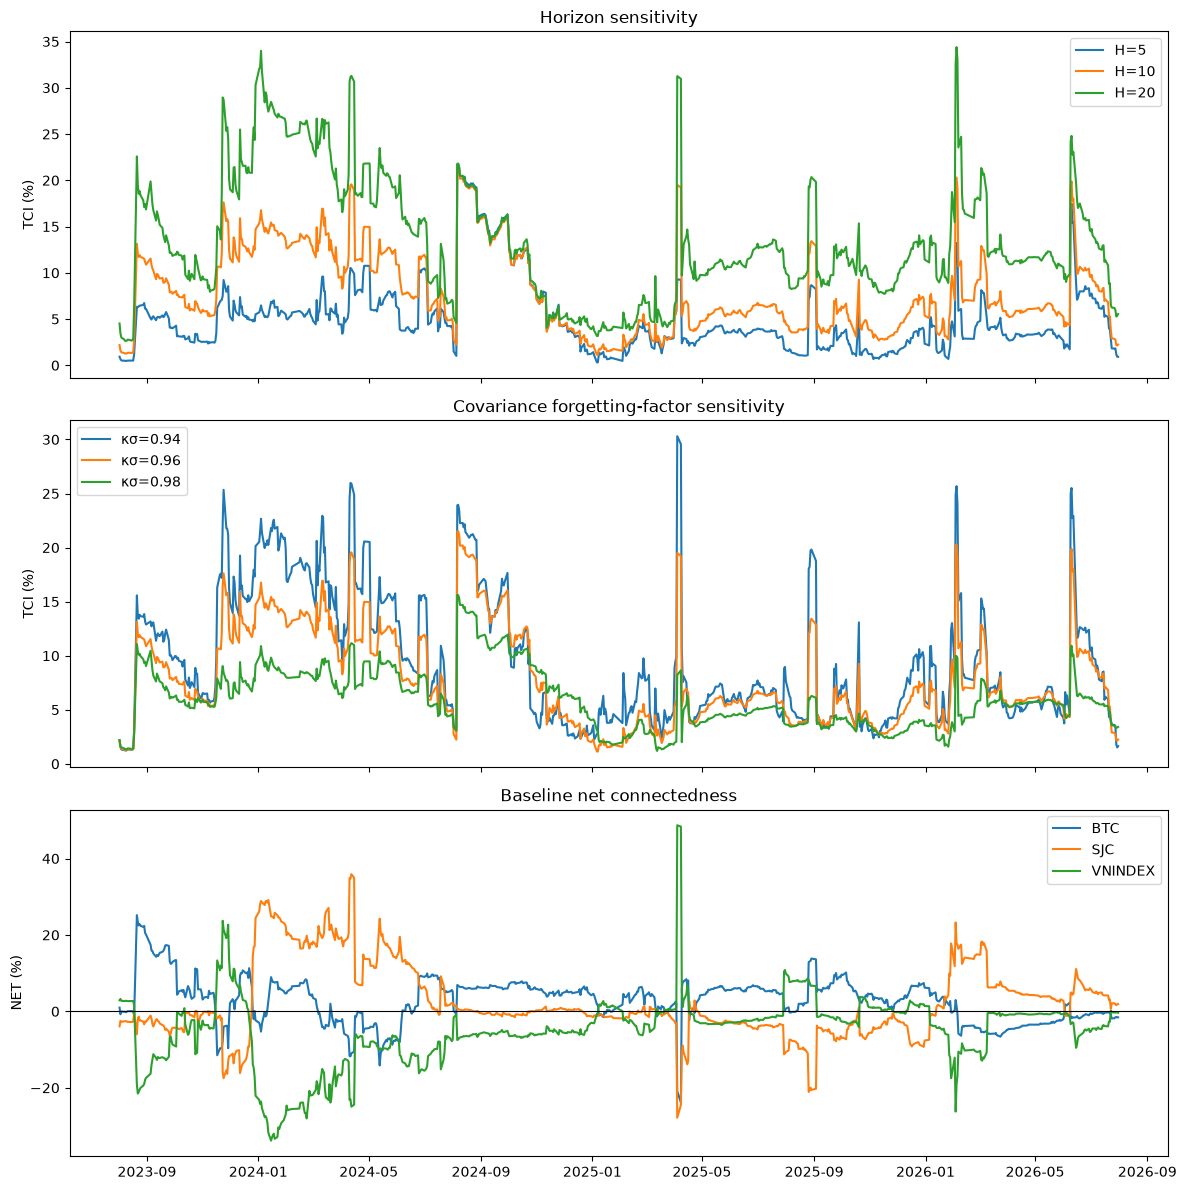

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for key in ['horizon_05', 'baseline_0999', 'horizon_20']:
    result = results[key]
    axes[0].plot(result.connectedness.tci, label=f'H={result.horizon}')
axes[0].set(title='Horizon sensitivity', ylabel='TCI (%)')
axes[0].legend()

for key in ['kappa_094', 'baseline_0999', 'kappa_098']:
    result = results[key]
    axes[1].plot(result.connectedness.tci, label=f"κσ={result.model.kappa_sigma}")
axes[1].set(title='Covariance forgetting-factor sensitivity', ylabel='TCI (%)')
axes[1].legend()

for variable in baseline.model.variables:
    axes[2].plot(baseline.connectedness.net[variable], label=variable)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set(title='Baseline net connectedness', ylabel='NET (%)')
axes[2].legend()
fig.tight_layout()
plt.show()

## Save reproducible outputs

Set `WRITE_OUTPUTS` to `False` if you only want to inspect results.

In [7]:
WRITE_OUTPUTS = False

if WRITE_OUTPUTS:
    for result in results.values():
        save_results(result, ROOT / 'outputs' / result.name)
    save_comparison(list(results.values()), ROOT / 'outputs' / 'specification_comparison.csv')
    print('Saved outputs/')

Saved outputs/


## Interpretation

Use the comparison table for full-sample average and final-period measures. Positive NET denotes a net transmitter, while negative NET denotes a net receiver. The stability table flags local coefficient matrices with spectral radius at least one; finite-horizon GFEVD results are retained and reported alongside that diagnostic.

## So sánh kết quả DY-VAR(9) và TVP-VAR(1)

### 1. Kết quả DY-VAR(9)

Tại horizon $H=10$, mô hình VAR(9) kết hợp với phân rã phương sai tổng quát GFEVD cho kết quả:

| Tài sản | OWN | FROM | TO | NET | Vai trò |
|---|---:|---:|---:|---:|---|
| BTC | 95,8504% | 4,1496% | 3,1278% | -1,0218% | Net receiver |
| SJC | 93,9896% | 6,0104% | 3,9990% | -2,0114% | Net receiver |
| VN-Index | 97,6583% | 2,3417% | 5,3749% | +3,0332% | Net transmitter |

Chỉ số kết nối tổng thể đạt:

$$
TCI_{DY}=4,1672\%.
$$

Kết quả cho thấy phần lớn biến động của mỗi tài sản được giải thích bởi các cú sốc nội tại. Tỷ lệ OWN lần lượt đạt 95,8504% đối với BTC, 93,9896% đối với SJC và 97,6583% đối với VN-Index.

VN-Index là nguồn truyền volatility ròng duy nhất vì có $NET>0$. Ngược lại, BTC và SJC là các thị trường nhận rủi ro ròng. SJC có mức FROM cao nhất, đạt 6,0104%, đồng thời có NET âm lớn nhất về trị tuyệt đối. Điều này cho thấy SJC chịu ảnh hưởng từ các cú sốc bên ngoài tương đối mạnh nhất trong hệ thống.

Kênh truyền nổi bật nhất là:

$$
VNINDEX \rightarrow SJC,
$$

với spillover ròng khoảng 4,35 điểm phần trăm. Như vậy, theo bức tranh trung bình của mô hình DY-VAR(9), biến động của VN-Index có xu hướng lan truyền sang thị trường vàng SJC.

### 2. Kết quả TVP-VAR(1)

#### 2.1. Trạng thái cuối mẫu

Tại thời điểm cuối mẫu, TVP-VAR(1) cho kết quả:

| Tài sản | OWN | FROM | TO | NET | Vai trò |
|---|---:|---:|---:|---:|---|
| BTC | 98,0591% | 1,9409% | 0,3761% | -1,5648% | Receiver |
| SJC | 97,9587% | 2,0413% | 3,9781% | +1,9368% | Transmitter |
| VN-Index | 97,2476% | 2,7524% | 2,3804% | -0,3720% | Receiver |

Chỉ số kết nối cuối mẫu là:

$$
TCI_{TVP,\,cuối}=2,2449\%.
$$

Ở cuối mẫu, mức độ kết nối thấp hơn kết quả DY-VAR(9). Các cú sốc riêng của từng tài sản chiếm tỷ trọng lớn hơn, trong khi spillover chéo giảm xuống.

Đáng chú ý, vai trò truyền và nhận rủi ro đã thay đổi. SJC chuyển thành net transmitter, còn VN-Index chuyển thành net receiver. BTC tiếp tục là net receiver và nhận nhiều volatility từ SJC hơn lượng volatility truyền sang các thị trường khác.

#### 2.2. Trung bình theo thời gian

Do TVP-VAR(1) cho phép các tham số thay đổi theo thời gian, cần phân biệt kết quả cuối mẫu với kết quả trung bình của toàn bộ giai đoạn. TCI trung bình của TVP-VAR(1) đạt:

$$
\overline{TCI}_{TVP}=7,9241\%.
$$

NET trung bình theo thời gian là:

| Tài sản | NET trung bình | Vai trò trung bình |
|---|---:|---|
| BTC | +2,8759% | Net transmitter |
| SJC | +2,2210% | Net transmitter |
| VN-Index | -5,0969% | Net receiver |

Do đó, trong phần lớn thời gian của mẫu, BTC và SJC có xu hướng truyền volatility ròng, còn VN-Index có xu hướng nhận volatility ròng.

### 3. So sánh hai mô hình

| Chỉ tiêu | DY-VAR(9) | TVP-VAR(1), cuối mẫu |
|---|---:|---:|
| TCI | 4,1672% | 2,2449% |
| BTC | Receiver | Receiver |
| SJC | Receiver | Transmitter |
| VN-Index | Transmitter | Receiver |
| Kênh truyền nổi bật | VN-Index → SJC | SJC → BTC |

#### 3.1. Tương đồng

Cả hai mô hình đều cho thấy:

1. Mức độ connectedness tổng thể không cao.
2. OWN shocks chiếm tỷ trọng lớn, khoảng 94% đến 98%, các thị trường chưa phụ thuộc quá mạnh vào các cú sốc từ thị trường khác.
3. BTC có vai trò receiver tại cuối mẫu trong cả hai cách tiếp cận.

Điều này cho thấy ba thị trường vẫn có đặc điểm riêng tương đối rõ và lợi ích đa dạng hóa vẫn tồn tại trong giai đoạn nghiên cứu.

#### 3.2. Khác biệt

Khác biệt lớn nhất nằm ở vai trò truyền và nhận rủi ro:

- TVP-VAR(1) cho phép hệ số và ma trận hiệp phương sai thay đổi theo thời gian. Vì vậy, mô hình phát hiện được sự chuyển đổi trong cấu trúc connectedness.
- Cuối mẫu, SJC trở thành net transmitter còn VN-Index trở thành net receiver.
- TCI cuối mẫu của TVP-VAR(1) thấp hơn TCI của DY-VAR(9), cho thấy connectedness tại thời điểm cuối mẫu thấp hơn mức kết nối tổng hợp của mô hình tĩnh. Ngược lại, TCI trung bình theo thời gian của TVP-VAR(1) đạt 7,9241%, cao hơn TCI của DY-VAR(9). Điều này cho thấy connectedness đã có những giai đoạn cao hơn đáng kể nhưng giảm xuống vào cuối mẫu.

### 4. Ý nghĩa kinh tế

Kết quả TVP-VAR cho thấy connectedness giữa BTC, SJC và VN-Index mang tính động và không thể được mô tả đầy đủ bằng một cấu trúc truyền dẫn cố định. Mặc dù phân tích DY-VAR trên toàn bộ mẫu cho thấy VN-Index là nguồn truyền volatility ròng, TVP-VAR cho thấy vai trò này thay đổi theo thời gian. BTC và SJC cũng không duy trì một vai trò truyền hoặc nhận volatility cố định, mà có thể chuyển đổi giữa hai trạng thái tùy thuộc vào điều kiện của hệ thống.

Tại cuối mẫu, SJC trở thành net transmitter trong khi BTC và VN-Index là net receivers. Đồng thời, TCI giảm xuống 2,2449%, cho thấy tại thời điểm cuối mẫu, các cú sốc nội tại chiếm ưu thế hơn so với spillover giữa các thị trường. Ngược lại, TCI trung bình theo thời gian đạt 7,9241%, cho thấy đã tồn tại những giai đoạn connectedness cao hơn đáng kể trong quá trình nghiên cứu.

Về quản trị rủi ro:

- VN-Index là nguồn rủi ro đáng chú ý khi xem xét bức tranh trung bình của toàn bộ mẫu.
- SJC là nguồn truyền rủi ro đáng chú ý ở cuối mẫu và là thị trường cần được theo dõi khi đánh giá rủi ro ngắn hạn hiện tại.
- BTC có vai trò receiver ở cuối mẫu, nhưng kết quả NET trung bình dương cho thấy BTC từng là transmitter trong nhiều giai đoạn.
- Lợi ích đa dạng hóa tồn tại nhưng không bất biến, vì hướng truyền rủi ro có thể đảo chiều theo thời gian.


### 5. Kết luận

Nhìn chung, nghiên cứu cho thấy BTC, vàng SJC và VN-Index không hình thành một hệ thống connectedness cao và ổn định, mà là một hệ thống có mức độ phụ thuộc chéo tương đối thấp nhưng biến động theo thời gian về cả cường độ lẫn hướng truyền rủi ro. TVP-VAR vì vậy bổ sung một khía cạnh quan trọng cho kết quả connectedness tổng thể: thay vì chỉ xác định tài sản nào truyền và tài sản nào nhận trong toàn bộ mẫu, mô hình cho thấy vai trò đó có thể thay đổi song song với trạng thái của hệ thống tài chính.